In [1]:
# ===============================
# 1️⃣ Install dependencies
# ===============================
!pip install transformers datasets torch scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ---------------------------------------- 0.0/527.0 kB ? eta -:--:--
   ------------------- -------------------- 262.1/527.0 kB ? eta -:--:--
   ---------------------------------------- 527.0/527.0 kB 1.5 MB/s  0:00:00

   --- ------------------------------------  1/12 [propcache]
  Attempting uninstall: fsspec
   --- ------------------------------------  1/12 [propcache]
   ---------- -----------------------------  3/12 [fsspec]
    Found existing installation: fsspec 2026.3.0
   ---------- -----------------------------  3/12 [fsspec]
    Uninstalling fsspec-2026.3.0:
   ---------- -----------------------------  3/12 [fsspec]
      Successfully uninstalled fsspec-2026.3.0
   ---------- -----------


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ===============================
# 2️⃣ Import libraries
# ===============================
import pandas as pd
import re
import torch
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
# ===============================
# 3️⃣ Load & clean dataset
# ===============================
df = pd.read_csv("C:/Users/kaviy/IMDB Dataset.csv")

# Remove HTML, special chars, lowercase
def clean_text(text):
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    return text.lower()

df['review'] = df['review'].apply(clean_text)

# Map sentiment to 0/1
df['label'] = df['sentiment'].map({'positive':1, 'negative':0})

# Optional: small subset for fast demo
df_small = df[:2000]

print("Cleaned dataset preview:")
print(df_small.head())

Cleaned dataset preview:
                                              review sentiment  label
0  one of the other reviewers has mentioned that ...  positive      1
1  a wonderful little production the filming tech...  positive      1
2  i thought this was a wonderful way to spend ti...  positive      1
3  basically theres a family where a little boy j...  negative      0
4  petter matteis love in the time of money is a ...  positive      1


In [3]:
# ===============================
# Tokenize reviews
# ===============================
from transformers import AutoTokenizer

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

# Tokenize the cleaned reviews
# truncation=True ensures sequences longer than max_length are cut
# padding=True adds padding to make all sequences same length
# max_length=128 is typical for sentiment analysis
encodings = tokenizer(
    list(df_small['review']), 
    truncation=True, 
    padding=True, 
    max_length=128
)

print("Tokenization done!")
print("Sample input_ids:", encodings['input_ids'][0])
print("Sample attention_mask:", encodings['attention_mask'][0])

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

C:\Users\kaviy\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\kaviy\.cache\huggingface\hub\models--distilbert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenization done!
Sample input_ids: [101, 2028, 1997, 1996, 2060, 15814, 2038, 3855, 2008, 2044, 3666, 2074, 11472, 2792, 2017, 3363, 2022, 13322, 2027, 2024, 2157, 2004, 2023, 2003, 3599, 2054, 3047, 2007, 2777, 5369, 2034, 2518, 2008, 4930, 2033, 2055, 11472, 2001, 2049, 24083, 1998, 4895, 10258, 2378, 8450, 5019, 1997, 4808, 2029, 2275, 1999, 2157, 2013, 1996, 2773, 2175, 3404, 2033, 2023, 2003, 2025, 1037, 2265, 2005, 1996, 8143, 18627, 2030, 5199, 3593, 2023, 2265, 8005, 2053, 17957, 2007, 12362, 2000, 5850, 3348, 2030, 4808, 2049, 2003, 13076, 1999, 1996, 4438, 2224, 1997, 1996, 2773, 4183, 2003, 2170, 11472, 2004, 2008, 2003, 1996, 8367, 2445, 2000, 1996, 17411, 4555, 3036, 2110, 7279, 4221, 12380, 2854, 2009, 7679, 3701, 2006, 14110, 2103, 2019, 6388, 2930, 1997, 1996, 3827, 2073, 2035, 1996, 102]
Sample attention_mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [4]:
# ===============================
# Prepare PyTorch Dataset
# ===============================
import torch

class IMDBDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels
        
    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item
    
    def __len__(self):
        return len(self.labels)

# Convert sentiment labels to 0 (negative) and 1 (positive)
label_map = {'negative': 0, 'positive': 1}
labels = df_small['sentiment'].map(label_map).tolist()

# Create dataset
train_dataset = IMDBDataset(encodings, labels)

print("Dataset created!")
print("Sample item:", train_dataset[0])


Dataset created!
Sample item: {'input_ids': tensor([  101,  2028,  1997,  1996,  2060, 15814,  2038,  3855,  2008,  2044,
         3666,  2074, 11472,  2792,  2017,  3363,  2022, 13322,  2027,  2024,
         2157,  2004,  2023,  2003,  3599,  2054,  3047,  2007,  2777,  5369,
         2034,  2518,  2008,  4930,  2033,  2055, 11472,  2001,  2049, 24083,
         1998,  4895, 10258,  2378,  8450,  5019,  1997,  4808,  2029,  2275,
         1999,  2157,  2013,  1996,  2773,  2175,  3404,  2033,  2023,  2003,
         2025,  1037,  2265,  2005,  1996,  8143, 18627,  2030,  5199,  3593,
         2023,  2265,  8005,  2053, 17957,  2007, 12362,  2000,  5850,  3348,
         2030,  4808,  2049,  2003, 13076,  1999,  1996,  4438,  2224,  1997,
         1996,  2773,  4183,  2003,  2170, 11472,  2004,  2008,  2003,  1996,
         8367,  2445,  2000,  1996, 17411,  4555,  3036,  2110,  7279,  4221,
        12380,  2854,  2009,  7679,  3701,  2006, 14110,  2103,  2019,  6388,
         2930,  1997

In [5]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=8,
    logging_steps=10
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset
)

trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
C:\Users\kaviy\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init

Step,Training Loss
10,0.693106
20,0.647437
30,0.657396
40,0.647342
50,0.595708
60,0.569825
70,0.443553
80,0.504551
90,0.336459
100,0.534989


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=250, training_loss=0.4738376169204712, metrics={'train_runtime': 2364.8251, 'train_samples_per_second': 0.846, 'train_steps_per_second': 0.106, 'total_flos': 66233699328000.0, 'train_loss': 0.4738376169204712, 'epoch': 1.0})

In [6]:
# ------------------------------------------
# AFTER MODEL TRAINING: SAVE, EVALUATE, PREDICT
# ------------------------------------------

from transformers import AutoTokenizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import torch

# -------------------
# 1. Save Model & Tokenizer
# -------------------
model.save_pretrained("distilbert-imdb")
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
tokenizer.save_pretrained("distilbert-imdb")

print("Model and tokenizer saved!")

# -------------------
# 2. Evaluate on Validation/Training Dataset
# -------------------
# If you have a validation set, replace 'train_dataset' with 'val_dataset'
predictions = trainer.predict(train_dataset)

# Get predicted labels
preds = predictions.predictions.argmax(-1)
true_labels = predictions.label_ids

# Compute metrics
accuracy = accuracy_score(true_labels, preds)
precision, recall, f1, _ = precision_recall_fscore_support(true_labels, preds, average='binary')
cm = confusion_matrix(true_labels, preds)

print("\n--- Evaluation Metrics ---")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:\n", cm)

# -------------------
# 3. Predict on New Text Samples
# -------------------
new_texts = [
    "I absolutely loved this movie! The plot was fantastic.",
    "Terrible film. I wasted my time."
]

# Tokenize
new_encodings = tokenizer(new_texts, truncation=True, padding=True, max_length=128, return_tensors="pt")

# Get model predictions
with torch.no_grad():
    outputs = model(**new_encodings)
    predicted_labels = torch.argmax(outputs.logits, dim=1)

# Map labels to sentiment
label_map = {0: "negative", 1: "positive"}
predicted_sentiments = [label_map[label.item()] for label in predicted_labels]

print("\n--- New Predictions ---")
for text, sentiment in zip(new_texts, predicted_sentiments):
    print(f"Text: {text}\nPredicted Sentiment: {sentiment}\n")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved!


C:\Users\kaviy\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



--- Evaluation Metrics ---
Accuracy: 0.9115
Precision: 0.93125
Recall: 0.8895522388059701
F1 Score: 0.9099236641221374
Confusion Matrix:
 [[929  66]
 [111 894]]

--- New Predictions ---
Text: I absolutely loved this movie! The plot was fantastic.
Predicted Sentiment: positive

Text: Terrible film. I wasted my time.
Predicted Sentiment: negative



In [10]:
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Matplotlib is building the font cache; this may take a moment.


Confusion Matrix:
                  Predicted Negative  Predicted Positive
Actual Negative                 929                  66
Actual Positive                 111                 894


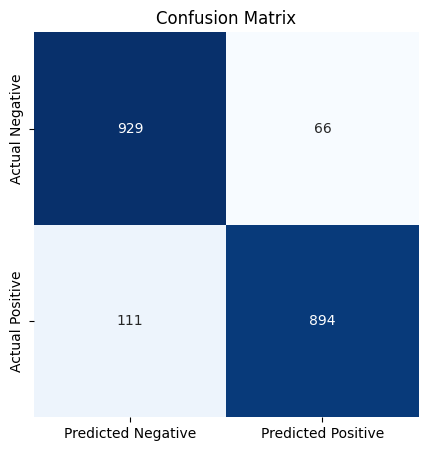

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Suppose you already have
# true_labels = predictions.label_ids
# preds = predictions.predictions.argmax(-1)

# Create confusion matrix
cm = confusion_matrix(true_labels, preds)

# Convert to DataFrame for better labels
cm_df = pd.DataFrame(cm, 
                     index=['Actual Negative', 'Actual Positive'],
                     columns=['Predicted Negative', 'Predicted Positive'])

# Print confusion matrix in console
print("Confusion Matrix:\n", cm_df)

# Plot heatmap
plt.figure(figsize=(5,5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, square=True)
plt.title("Confusion Matrix")
plt.show()